In [1]:
import json
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.utils import resample
import scipy.stats as stats
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

matplotlib.rcParams['font.family'] = 'serif' 
matplotlib.rcParams['font.serif'] = ['DejaVu Serif']

pd.set_option('display.float_format', lambda x: '%.2f' % x)

PARAMS = json.load(open("params.json", "r"))

SEED = PARAMS["SEED"]
S_MAX = PARAMS["S_MAX"]
S_MIN = PARAMS["S_MIN"]

ESSAY_SET = PARAMS["ESSAY_SET"]

SCALER_NAME = "Z"
MODEL_PATH = f"lr_{SCALER_NAME}_C/pred/llm/w_r_sf/nllf_ef"
WEAK_SIGNAL_NAME = "llm"
FEATURE_SET = "nllf_ef"

FS_STRATEGY = "C"
NON_NEGATIVE = True

NUM_EXAMPLES = 8

assert WEAK_SIGNAL_NAME in MODEL_PATH
assert FEATURE_SET in MODEL_PATH
assert SCALER_NAME in MODEL_PATH
assert FS_STRATEGY in MODEL_PATH
assert ("all" not in MODEL_PATH) == NON_NEGATIVE

METADATA = {
    "S_MAX": S_MAX,
    "S_MIN": S_MIN,
    "ESSAY_SET": ESSAY_SET,
    "MODEL_PATH": MODEL_PATH,
    "WEAK_SIGNAL_NAME": WEAK_SIGNAL_NAME,
    "FEATURE_SET": FEATURE_SET,
    "SCALER_NAME": SCALER_NAME,
    "FS_STRATEGY": FS_STRATEGY,
    "NON_NEGATIVE": NON_NEGATIVE,
    "NUM_EXAMPLES": NUM_EXAMPLES
}

In [2]:
def quadratic_weighted_kappa(y_true, y_pred, s_min, s_max):
    """
    Calculate the Quadratic Weighted Kappa (QWK) between two raters.

    Args:
    y_true (np.array): The true labels or ratings (Rater B).
    y_pred (np.array): The predicted labels or ratings (Rater A).
    L (int): The number of possible score categories.

    Returns:
    float: The QWK score.
    """

    # Create the weights matrix
    w = np.zeros((s_max-s_min+1, s_max-s_min+1))
    for i in range(s_max-s_min+1):
        for j in range(s_max-s_min+1):
            w[i, j] = ((i - j) ** 2) / ((s_max - s_min) ** 2)

    # Calculate the O (observed) matrix
    O = np.histogram2d(y_true, y_pred, bins=s_max-s_min+1, range=[[s_min, s_max], [s_min, s_max]])[0]

    # Calculate the E (expected) matrix
    hist_true = np.histogram(y_true, bins=s_max-s_min+1, range=[s_min, s_max])[0]
    hist_pred = np.histogram(y_pred, bins=s_max-s_min+1, range=[s_min, s_max])[0]
    E = np.outer(hist_true, hist_pred) / len(y_true)

    # Compute QWK
    num = np.sum(w * O)
    denom = np.sum(w * E)
    kappa = 1 - (num / denom)

    return kappa

def bootstrap(X, y, w, model, scale, loc, n_bootstrap=1000, alpha=0.05):
    """
    Compute confidence intervals for both the intercept and coefficients using bootstrapping.
    :param X: Design matrix (n x p)
    :param y: Observed values (n,)
    :param w: Weights (n,)
    :param model: The fitted regression model
    :param n_bootstrap: Number of bootstrap resamples
    :param alpha: Significance level for confidence interval (e.g., 0.05 for 95% CI)
    :return: Confidence intervals for coefficients and intercept (p+1 x 2)
    """
    bootstrap_coefs = np.zeros((n_bootstrap, X.shape[1]))  # Store coefficients from each bootstrap sample
    bootstrap_intercepts = np.zeros(n_bootstrap)  # Store intercepts from each bootstrap sample
    
    # Generate bootstrap samples and fit the model
    for i in range(n_bootstrap):
        X_resample, y_resample, w_resample = resample(X, y, w, random_state=i)
        model.fit(X_resample, y_resample, sample_weight=w_resample)
        
        # Store the intercept and coefficients
        bootstrap_intercepts[i] = loc + scale * model.intercept_
        bootstrap_coefs[i] = scale * model.coef_
    
    # Combine intercept and coefficients into one array for percentiles
    all_coefs = np.column_stack((bootstrap_intercepts, bootstrap_coefs))
    
    # Compute the lower and upper percentiles for each parameter (intercept + coefficients)
    lower_bound = np.percentile(all_coefs, 100 * alpha / 2, axis=0)
    upper_bound = np.percentile(all_coefs, 100 * (1 - alpha / 2), axis=0)
    
    # Return confidence intervals for intercept and coefficients
    return all_coefs, np.vstack((lower_bound, upper_bound)).T

def compute_statistics(coefficients, boostrap_coefficients, ci):
    """
    Compute standard error, t-statistics, p-values, and absolute t-statistics
    based on the bootstrap coefficients.
    :param coefficients: Coefficients from WNLS (n_bootstrap x p)
    :param ci: Confidence intervals for coefficients (p x 2)
    :return: Dataframe with the statistics
    """
    # Calculate the mean (coef) and standard deviation (std err) of the bootstrap coefficients
    coef = coefficients
    coef_mean = np.mean(boostrap_coefficients, axis=0)
    std_err = np.std(boostrap_coefficients, axis=0)
    
    # Calculate t-statistics
    t_stats = coef_mean / std_err
    
    # Calculate p-values based on t-distribution
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=coefficients.shape[0]-1))
    
    # Build the dataframe
    df = pd.DataFrame({
        'coef': coef,
        'mean': coef_mean,
        'std err': std_err,
        't': t_stats,
        'P>|t|': p_values,
        '[0.025': ci[:, 0],
        '0.975]': ci[:, 1],
        '|t|': np.abs(t_stats),
        "|coef|": np.abs(coef),
    })
    
    return df

def p_value_to_stars(p_value, alpha=0.05):
    """
    Convert a p-value to stars based on significance level alpha.
    
    Parameters:
        p_value (float): The p-value to convert.
        alpha (float): The significance level (default is 0.05).
        
    Returns:
        str: A string containing asterisks representing significance levels.
    """
    if p_value < alpha / 100:
        return '***'
    elif p_value < alpha / 20:
        return '**'
    elif p_value < alpha / 10:
        return '*'
    else:
        return ''

def plot_model_weights(model_path, significant_features, bias):
    # Create a vertical layout with 2 subplots
    fig, ax = plt.subplots(1, 2, figsize=(9, 4), dpi=120)  # Slightly larger for better readability

    dx = 0.3
    eps = 0.1

    # EF Plot (Top 5)
    coef_top = significant_features.iloc[:5]["coef"][::-1]
    ci_top_lower = significant_features.iloc[:5]["[0.025"][::-1]
    ci_top_upper = significant_features.iloc[:5]["0.975]"][::-1]

    ax[0].errorbar(coef_top, range(5), 
                xerr=[coef_top - ci_top_lower, ci_top_upper - coef_top], 
                fmt='o', color='tab:blue', ecolor='lightgray', capsize=3, label=f"Coef.\n(95% CI)\nBias = {bias:.2f}")

    # NLLF Plot (Top 5)
    coef_bottom = significant_features.iloc[5:]["coef"][::-1]
    ci_bottom_lower = significant_features.iloc[5:]["[0.025"][::-1]
    ci_bottom_upper = significant_features.iloc[5:]["0.975]"][::-1]

    ax[1].errorbar(coef_bottom, range(5), 
                xerr=[coef_bottom - ci_bottom_lower, ci_bottom_upper - coef_bottom], 
                fmt='o', color='tab:blue', ecolor='lightgray', capsize=3, label="Coef.\n(95% CI)")

    # Add horizontal reference lines at 0 (for both plots)
    ax[0].axvline(x=0, color="red", linestyle="--", alpha=0.6, label="Zero\nReference")
    ax[1].axvline(x=0, color="red", linestyle="--", alpha=0.6, label="Zero Reference")


    ll_nllf = 4
    textstr_nllf = lambda ix: f"{ix}" if len(ix.split(' ')) <= ll_nllf else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}" if len(ix.split(' '))<=ll_nllf*2 else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[2*ll_nllf:3*ll_nllf]).strip()}" if len(ix.split(' ')) <= 3*ll_nllf else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[2*ll_nllf:3*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[3*ll_nllf:4*ll_nllf]).strip()}" if len(ix.split(' ')) <= 4*ll_nllf else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[2*ll_nllf:3*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[3*ll_nllf:4*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[4*ll_nllf:]).strip()}"
            
    ll_ef = 3
    textstr_ef = lambda ix: f"{ix}" if len(ix.split(' ')) <= ll_ef else f"{' '.join(ix.split(' ')[:ll_ef]).strip()}\n{' '.join(ix.split(' ')[ll_ef:2*ll_ef]).strip()}" if len(ix.split(' '))<=ll_ef*2 else f"{' '.join(ix.split(' ')[:ll_ef]).strip()}\n{' '.join(ix.split(' ')[ll_ef:2*ll_ef]).strip()}\n{' '.join(ix.split(' ')[2*ll_ef:3*ll_ef]).strip()}" if len(ix.split(' ')) <= 3*ll_ef else f"{' '.join(ix.split(' ')[:ll_ef]).strip()}\n{' '.join(ix.split(' ')[ll_ef:2*ll_ef]).strip()}\n{' '.join(ix.split(' ')[2*ll_ef:3*ll_ef]).strip()}\n{' '.join(ix.split(' ')[3*ll_ef:]).strip()}"
            

    text_nllf = [
        textstr_nllf(ix)
        for k, ix in enumerate(significant_features.iloc[5:].index)
    ][::-1]

    text_ef = [
        textstr_ef(ix)
        for k, ix in enumerate(significant_features.iloc[:5].index)
    ][::-1]


    # Set y-axis labels with feature names for both plots
    ax[0].set_yticks(range(5))
    ax[0].set_yticklabels(text_ef, fontsize=9)  # Top 5 features (EF)

    ax[1].set_yticks(range(5))
    ax[1].set_yticklabels(text_nllf, fontsize=9)  # Last 5 features (NLLF)

    ax[0].set_ylim(-dx-eps, 4+dx+eps)
    ax[1].set_ylim(-dx-eps, 4+dx+eps)

    # Set updated titles
    ax[0].set_title("EF", fontsize=10, pad=10)
    ax[1].set_title("NLLF", fontsize=10, pad=10)

    fig.suptitle("Top 5 Features with the Highest Coefficients ", ha="center", fontsize=12, y=.95, x=0.48)

    # Set global x-axis label
    fig.text(0.48, 0.0, "Coefficient Weights with 95% Confidence Interval", ha='center', fontsize=10)

    # Move the y-ticks to the right
    ax[0].tick_params(axis='y', direction='out', length=6, labelright=False, labelleft=True, right=False, left=True)
    ax[1].tick_params(axis='y', direction='out', length=6, labelright=True, labelleft=False, right=True, left=False)

    # Add legends
    ax[0].legend(loc="best", fontsize=8)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Save the figure
    plt.savefig(f"{model_path}/coefficient_analysis.pdf", bbox_inches='tight', transparent=True)

    # Show the plot
    plt.show()

def plot_essay_feature_importance(model_path, igs, prompt, essay_id, rename, k=10, max_chars=500, move_text=0):
    # Filter the DataFrame for the specific essay_id
    df_row = igs[igs['essay_id'] == essay_id].iloc[0]
    
    # Extract real score, predicted score, and essay text
    real_score = df_row['test']
    predicted_score = df_row['pred']
    essay_text = df_row['essay']
    
    # Truncate the essay text if it exceeds max_chars
    if len(essay_text) > max_chars:
        essay_text = essay_text[:max_chars] + "..."
    
    # Extract attribution scores, linguistic features (LF), and NLLF features
    feature_columns = [col for col in igs.columns if col not in ['essay_id', 'test', 'pred', 'essay', 'const']]
    nllf_features = [col for col in feature_columns if all(['c' in col, "(" in col, ")" in col])]  # NLLF features start with 'c'
    lf_features = [col for col in feature_columns if 'ulra_' in col]  # Linguistic features (LF) start with 'ulra_'
    
    # Select the top-k absolute feature importance
    attributions = {col: df_row[col] for col in feature_columns}
    sorted_attributions = sorted(attributions.items(), key=lambda x: abs(x[1]), reverse=True)[:k]
    
    # Create two lists to store feature names and their corresponding values
    features = [f[0] for f in sorted_attributions]
    values = [f[1] for f in sorted_attributions]

    
    # Classify features as NLLF or LF based on their names
    colors = ['tab:blue' if f in nllf_features else 'tab:orange' for f in features]  # Blue for NLLF, Red for LF
    
    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 9), dpi=120)
    
    # Create two subplots: one for the essay and one for the feature importance barplot
    ax[0].axis('off')  # No axis for the text box
    ax[0].text(0.05+0.18, 1.059-0.28+0.03-0.17+0.025+0.06+move_text,f'Essay', horizontalalignment='center', fontsize=12)#, fontweight='bold')
    ax[0].text(0.23, 1-0.25+0.03-0.17+0.025+0.06+move_text, essay_text, fontsize=10, verticalalignment='top', horizontalalignment='center', 
               wrap=True, 
               bbox=dict(boxstyle='round,pad=0.3',facecolor='lightyellow', alpha=0, edgecolor="tab:olive"))

    ax[0].text(0.05+0.18, 1.059-0.28+0.03+0.05,f'Prompt', horizontalalignment='center', fontsize=12)#, fontweight='bold')
    ax[0].text(0.23, 1-0.25+0.03+0.05, prompt, fontsize=10, verticalalignment='top', horizontalalignment='center', 
               wrap=True, 
               bbox=dict(boxstyle='round,pad=0.3',facecolor='lightgrey', alpha=0.5, edgecolor="black"))
    
    # Rename features if they exist in the 'rename' dictionary, otherwise keep original names

    ll_nllf = 4

    textstr_nllf = lambda ix: f"{ix}" if len(ix.split(' ')) <= ll_nllf else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}" if len(ix.split(' '))<=ll_nllf*2 else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[2*ll_nllf:3*ll_nllf]).strip()}" if len(ix.split(' ')) <= 3*ll_nllf else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[2*ll_nllf:3*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[3*ll_nllf:4*ll_nllf]).strip()}" if len(ix.split(' ')) <= 4*ll_nllf else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[2*ll_nllf:3*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[3*ll_nllf:4*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[4*ll_nllf:]).strip()}"
        
    ll_ef = 3

    textstr_ef = lambda ix: f"{ix}" if len(ix.split(' ')) <= ll_ef else f"{' '.join(ix.split(' ')[:ll_ef]).strip()}\n{' '.join(ix.split(' ')[ll_ef:2*ll_ef]).strip()}" if len(ix.split(' '))<=ll_ef*2 else f"{' '.join(ix.split(' ')[:ll_ef]).strip()}\n{' '.join(ix.split(' ')[ll_ef:2*ll_ef]).strip()}\n{' '.join(ix.split(' ')[2*ll_ef:3*ll_ef]).strip()}" if len(ix.split(' ')) <= 3*ll_ef else f"{' '.join(ix.split(' ')[:ll_ef]).strip()}\n{' '.join(ix.split(' ')[ll_ef:2*ll_ef]).strip()}\n{' '.join(ix.split(' ')[2*ll_ef:3*ll_ef]).strip()}\n{' '.join(ix.split(' ')[3*ll_ef:]).strip()}"
        
    renamed_features = [textstr_nllf(rename.get(f, f)) if f in nllf_features else textstr_ef(rename.get(f, f)) if f in lf_features else f for f in features]

    ax[1].set_axisbelow(True)
    ax[1].xaxis.grid(color='gray', linestyle='-')

    # Barplot for feature importance
    sns.barplot(x=values, y=renamed_features, palette=colors, orient='h', ax=ax[1], dodge=False, alpha=0.6)
    ax[1].set_xlabel('Feature Attribution Score')
    plt.title(f'Top-{k} Higher\nFeature Attribution Score')#, fontweight='bold')

    # Annotate bars with the actual values
    pos_sum = sum([v for v in values if v>0])
    neg_sum = sum([v for v in values if v<0])
    for i, v in enumerate(values):
        ax[1].text(v+0.02, i, f'{ v:.2f}\n({v/pos_sum:.2f})' if v>0 else f'{ v:.2f}\n({v/neg_sum:.2f})' if v<0 else f'{ v:.2f}', color='black', va='center', alpha=0.7)# , fontweight='bold')
    
    # Customize y-axis labels and ticks
    ax[1].tick_params(axis='y', direction='out', length=6, labelright=True, labelleft=False, right=True, left=False)
    
    # Customize the borders of the bars
    for patch in ax[1].patches:
        patch.set_edgecolor(patch._original_facecolor)  # Set the border color to black
        patch.set_linewidth(1.3)  # Set the thickness of the border
    

    # Add value boxes for real and predicted scores
    ax[0].text(0.05-0.3, 1.01-0.055,f'Scores', horizontalalignment='left', fontsize=12)#, fontweight='bold')
    ax[0].text(0.05+0.4-0.165, 1.01-0.07, f'Real:\n{real_score:.1f}', horizontalalignment='left', fontsize=10, bbox=dict(boxstyle='round,pad=0.3',facecolor='tab:gray', alpha=0.3, edgecolor="black"))
    ax[0].text(0.05+0.58-0.165, 1.01-0.07, f'Predicted:\n{predicted_score:.1f}', horizontalalignment='left', fontsize=10, bbox=dict(boxstyle='round,pad=0.3',facecolor='lightgreen', alpha=0.4, edgecolor="tab:green"))
    
    # Add score range annotation
    ax[0].text(0.05-0.0, 1.01-0.07, f'Range:\n[{S_MIN}, {S_MAX}]', horizontalalignment='left', fontsize=10, bbox=dict(boxstyle='round,pad=0.3',facecolor='lightblue', alpha=0.4, edgecolor="tab:blue"))

    # Add legend for NLLF and LF
    handles = [plt.Line2D([0], [0], color='tab:blue', lw=4), plt.Line2D([0], [0], color='tab:orange', lw=4)]
    labels = ['NLLF', 'Linguistic\nFeatures']
    ax[1].legend(handles, labels, title='Feature Types', loc="lower left" if abs(min(values)) > max(values) else "lower right", fontsize=10, title_fontsize=10)
    ax[1].set_xlim([min(0, min(values)*1.4), max(0, (max(values)+0.06)*1.4)])

    fig.set_size_inches(fig.get_size_inches() * np.array([1, 1]), forward=True)

    plt.tight_layout(pad=4)
    plt.savefig(f"{model_path}/interpret_{essay_id}.pdf", bbox_inches='tight', transparent=True)
    plt.show()

/tmp/ipykernel_1593287/1519752497.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[k]["score"] = df_gt.loc[df[k].index]["pred"]
/tmp/ipykernel_1593287/2980686971.py:82: RuntimeWarning: invalid value encountered in divide
  t_stats = coef_mean / std_err


feature: The essay has a clear and logical organization
Corr.: 0.02
Mean: 0.3699228954009919


feature: The essay uses logical reasoning to support its position on censorship
Corr.: 0.02
Mean: 0.5018383214043246


feature: The essay does not fail in supporting its opinion, summarizing effectively, telling a coherent story, or presenting clear information
Corr.: 0.03
Mean: 0.9308935501923163


feature: The essay uses appropriate language and tone for the intended audience and purpose
Corr.: 0.02
Mean: 0.45219565767329184


feature: The essay flows smoothly without any abrupt changes in the direction of the argument
Corr.: 0.02
Mean: 0.45054541237704043


feature: The essay takes a clear position on whether or not to remove offensive materials from libraries
Corr.: 0.01
Mean: 0.6552715220074686


feature: The essay maintains a consistent length of responses without being overly brief or rambling and repetitive
Corr.: 0.02
Mean: 0.4925275059882551


feature: The essay provides a thorough 

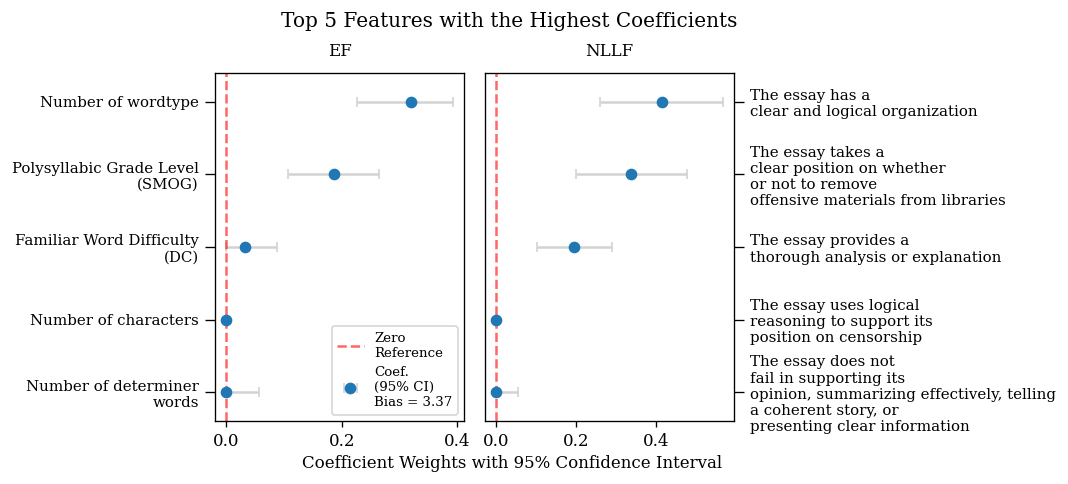

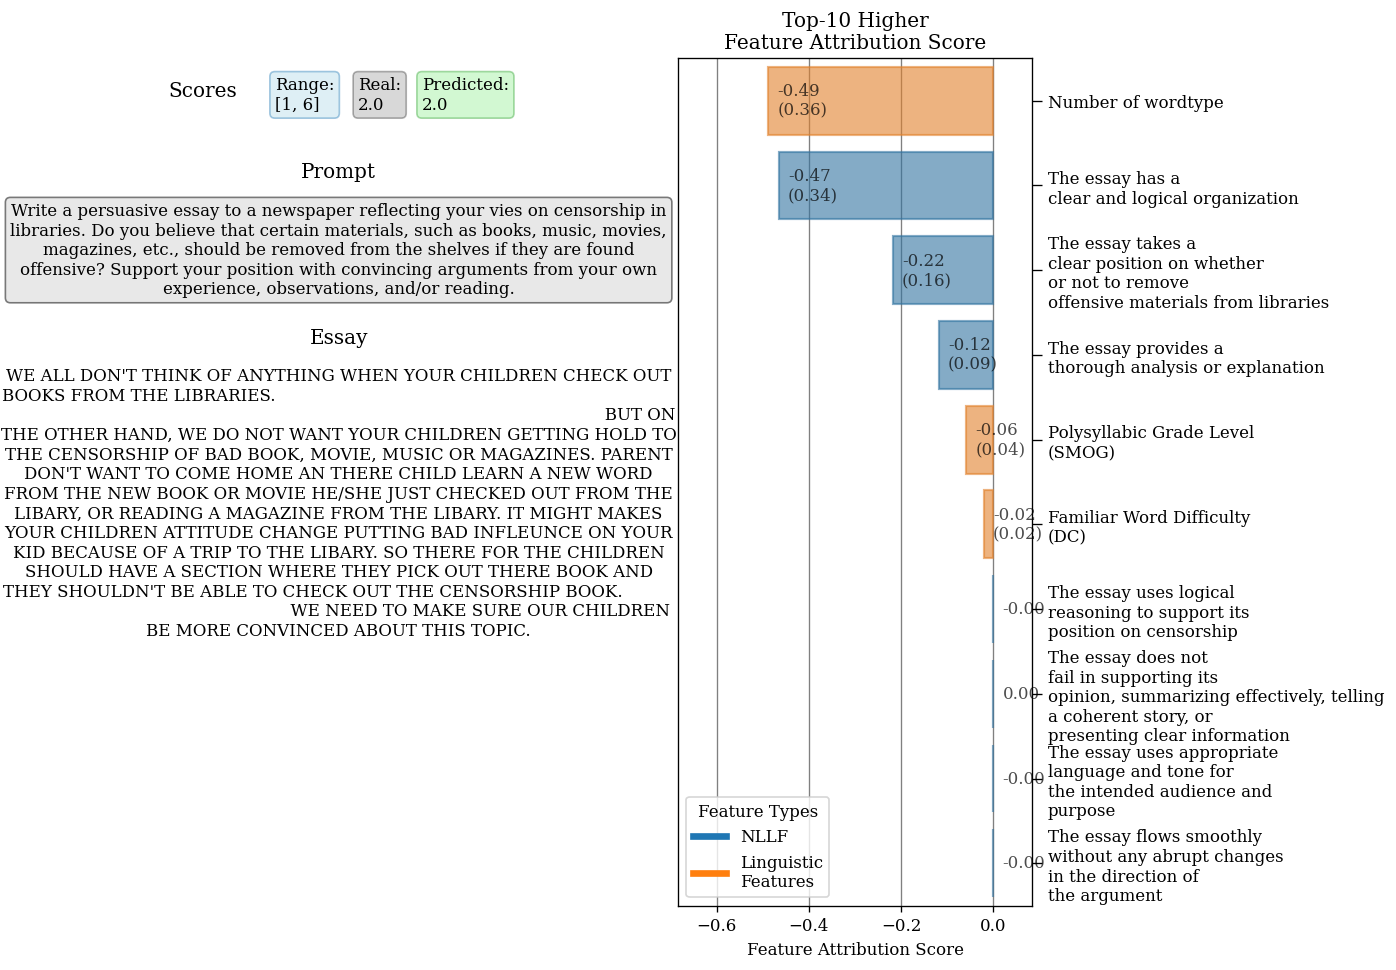

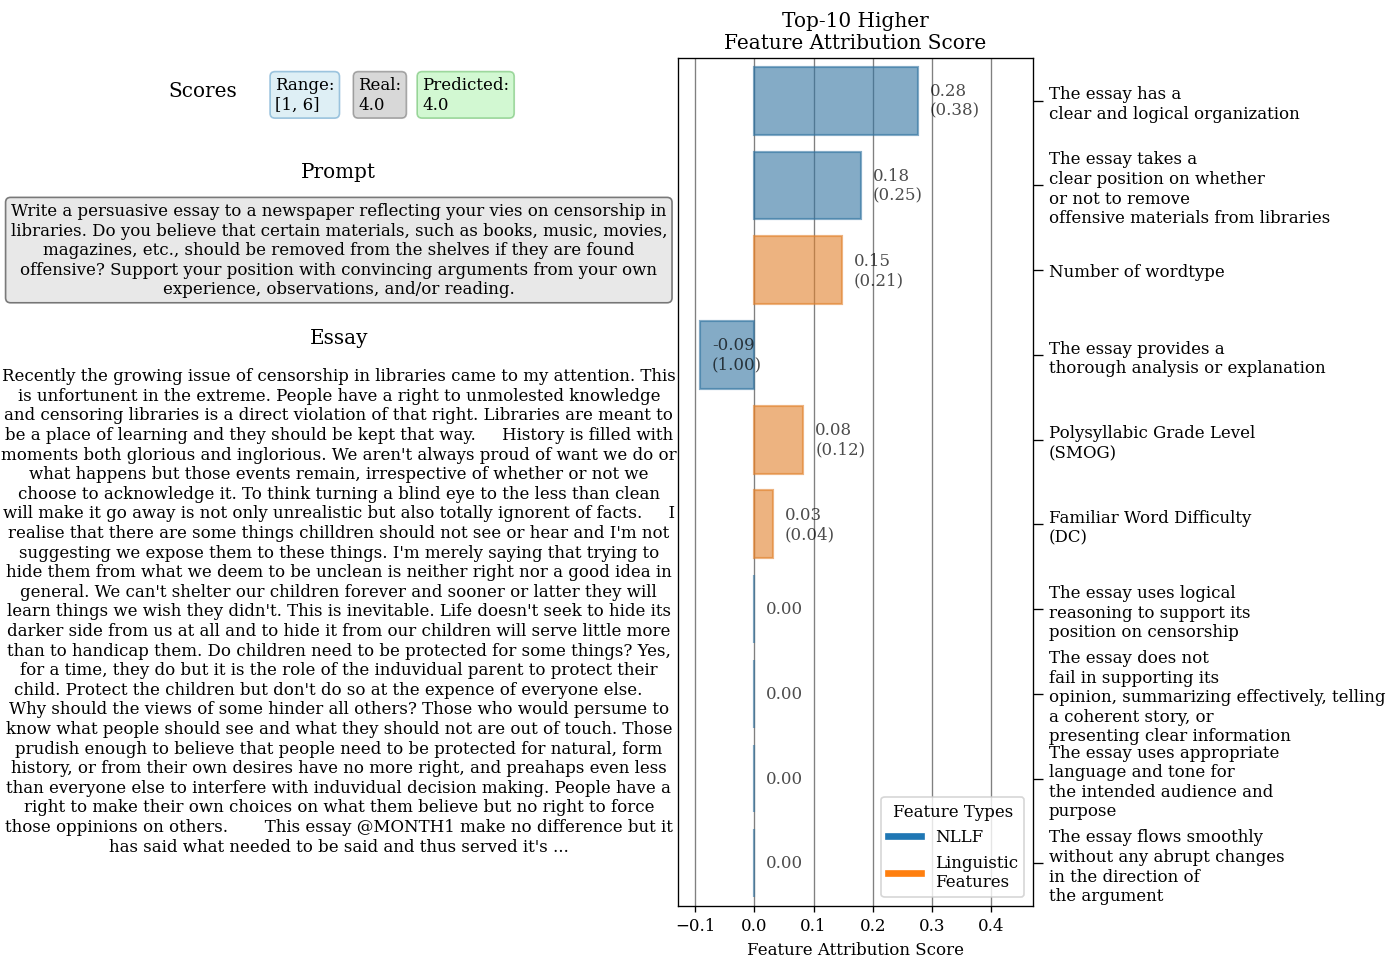

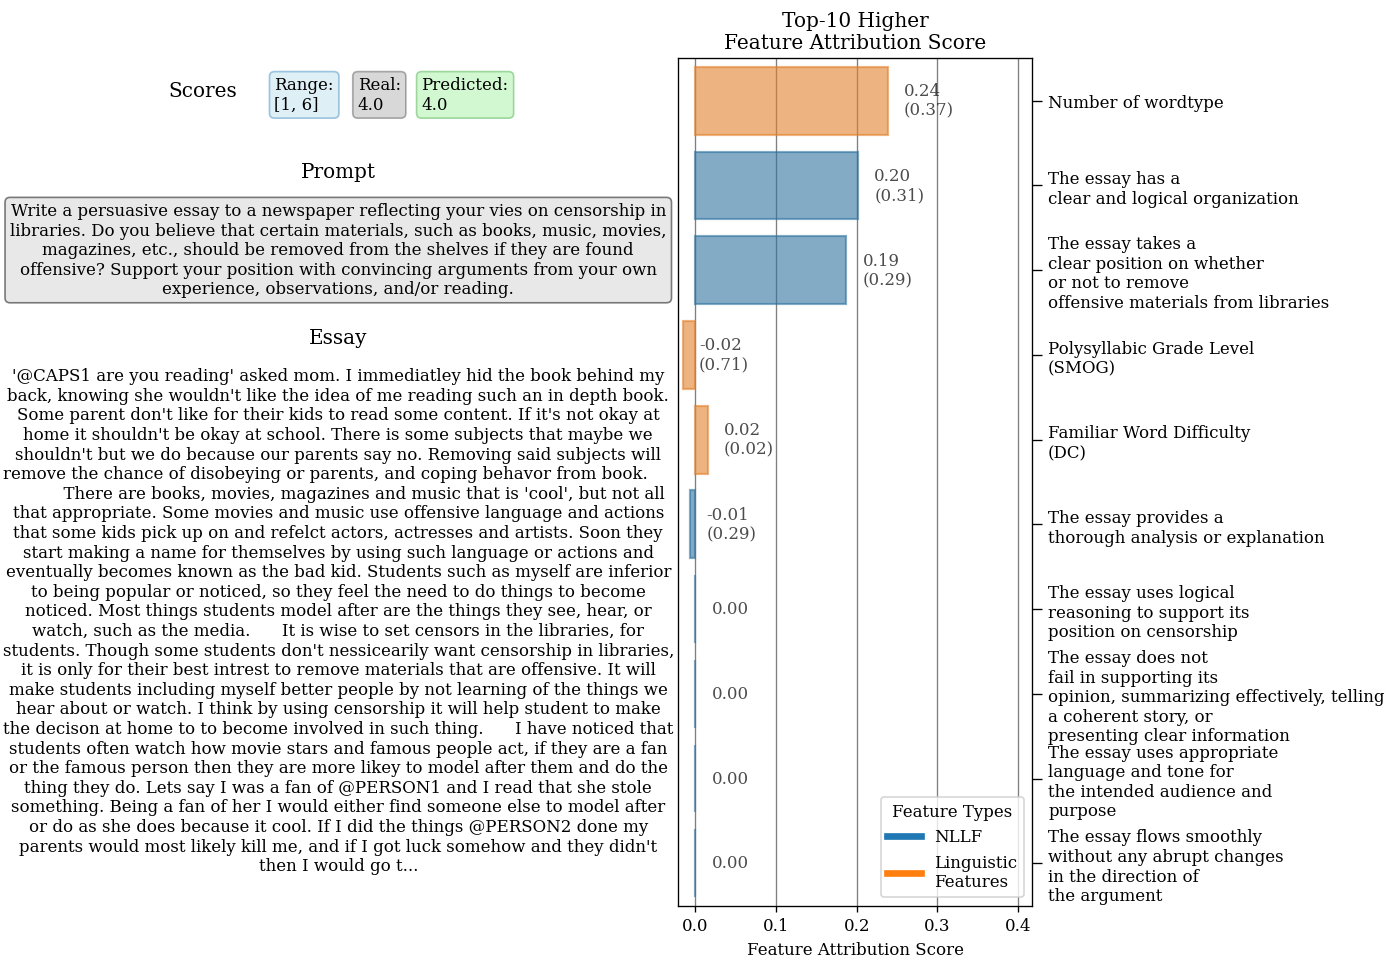

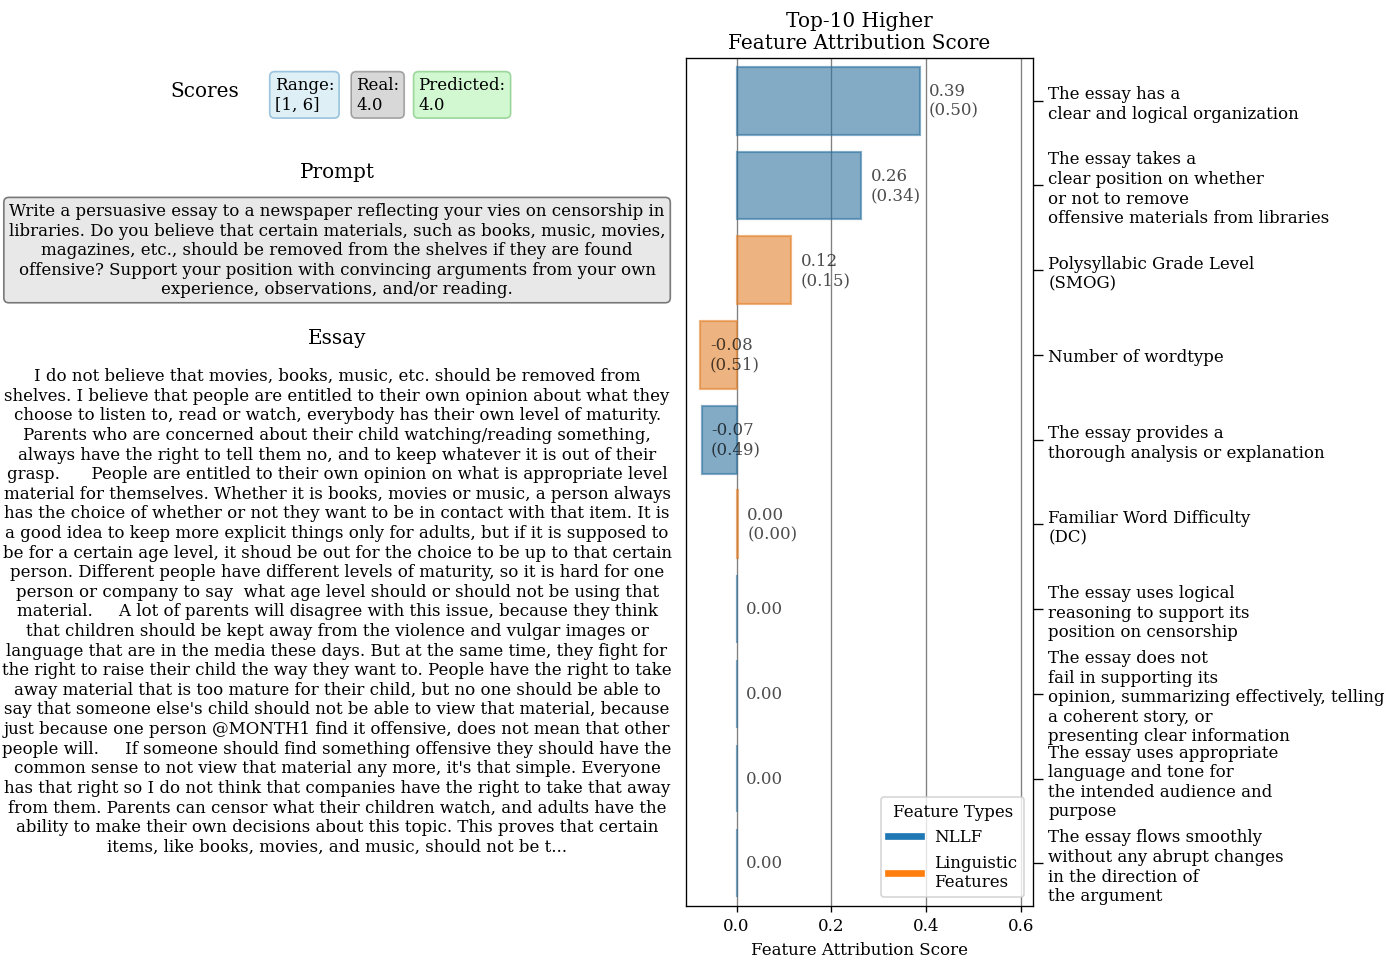

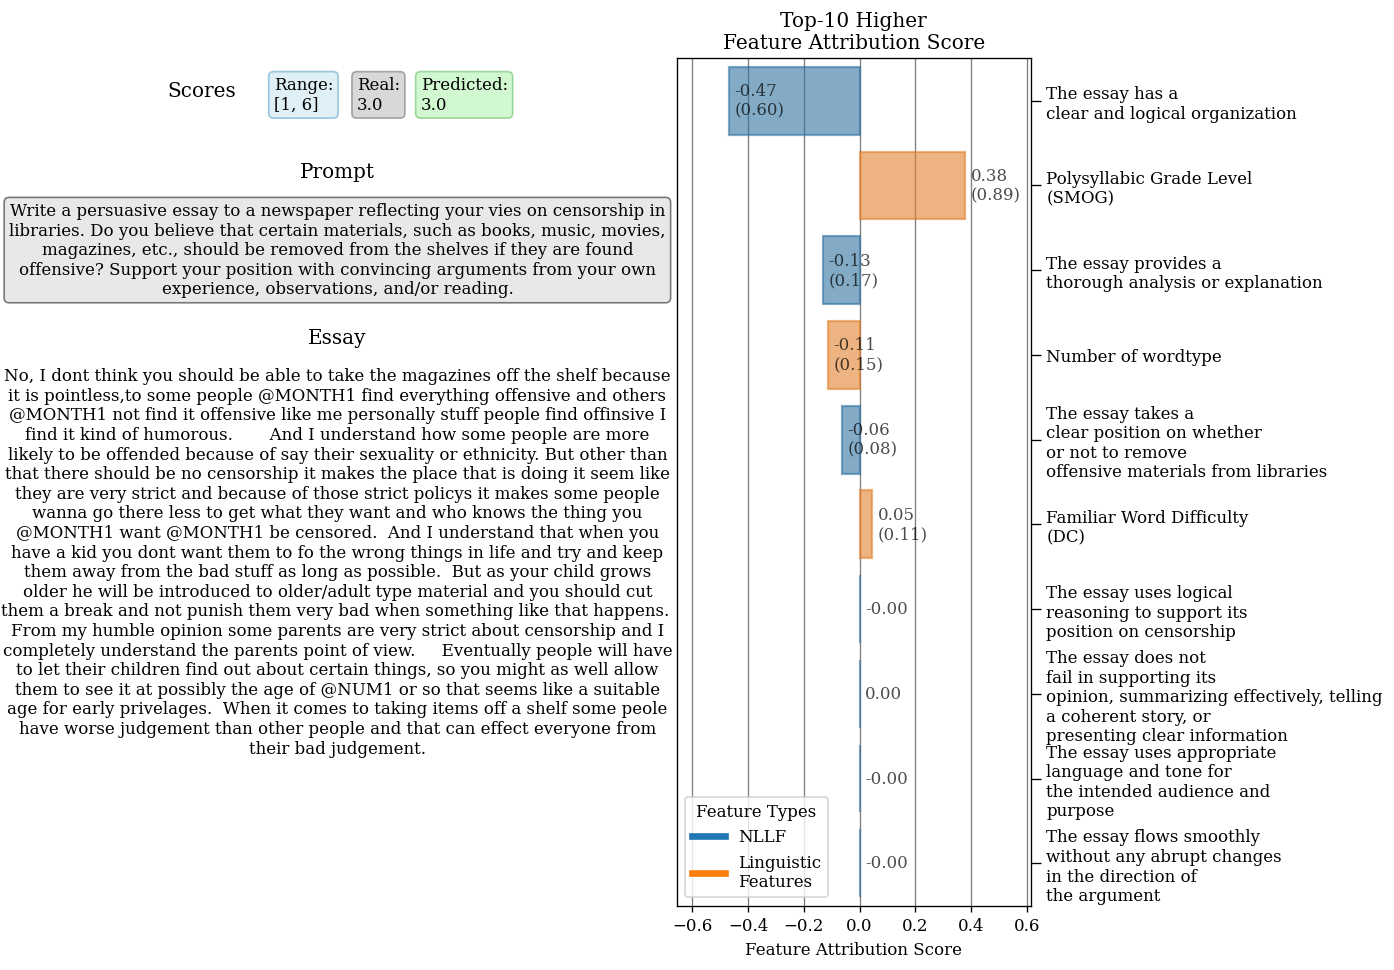

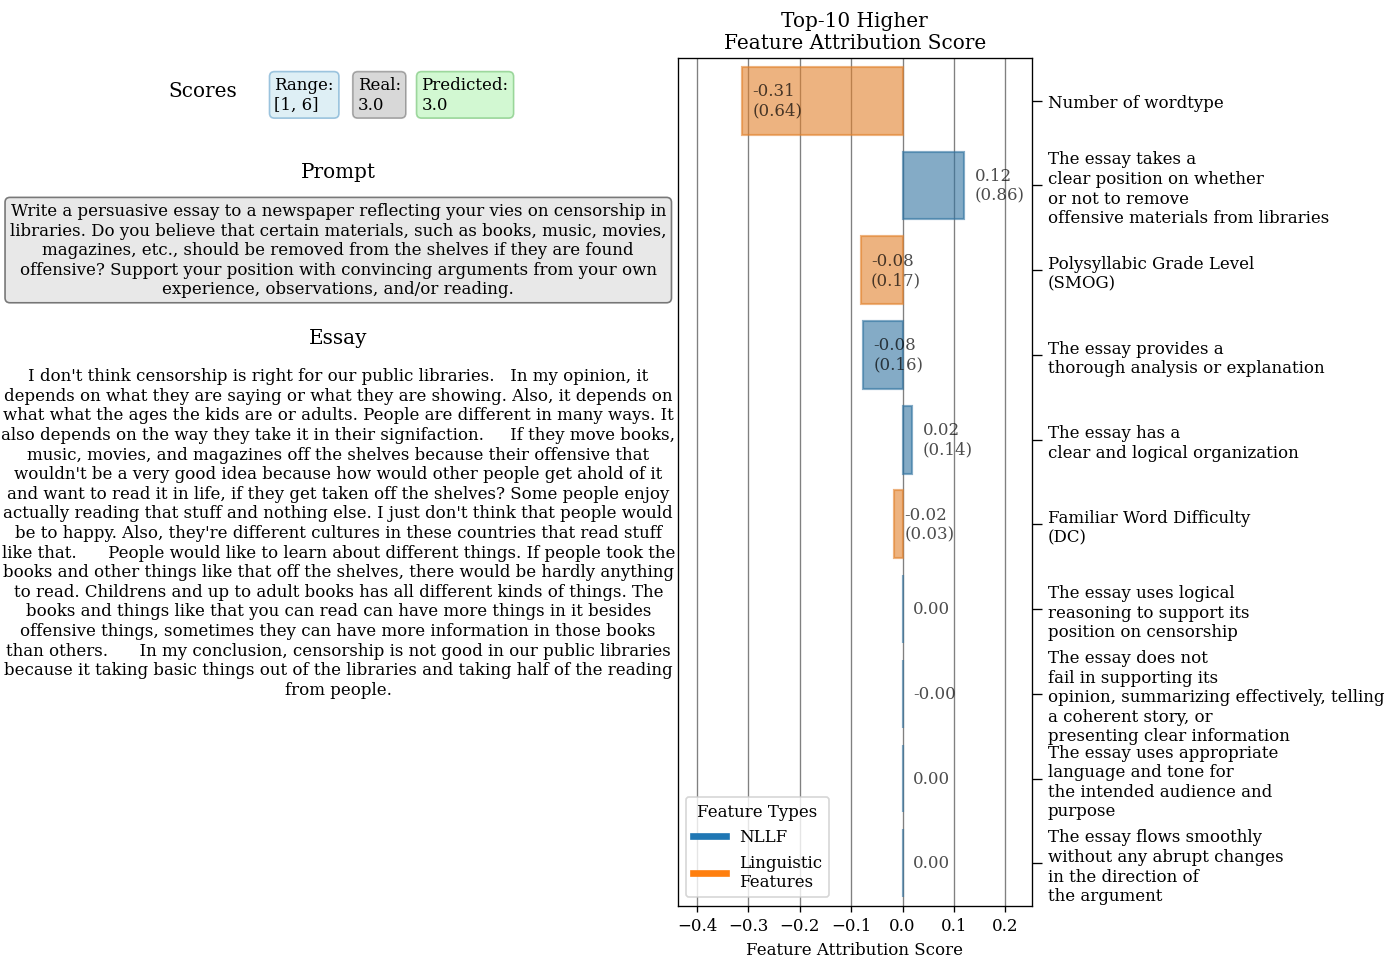

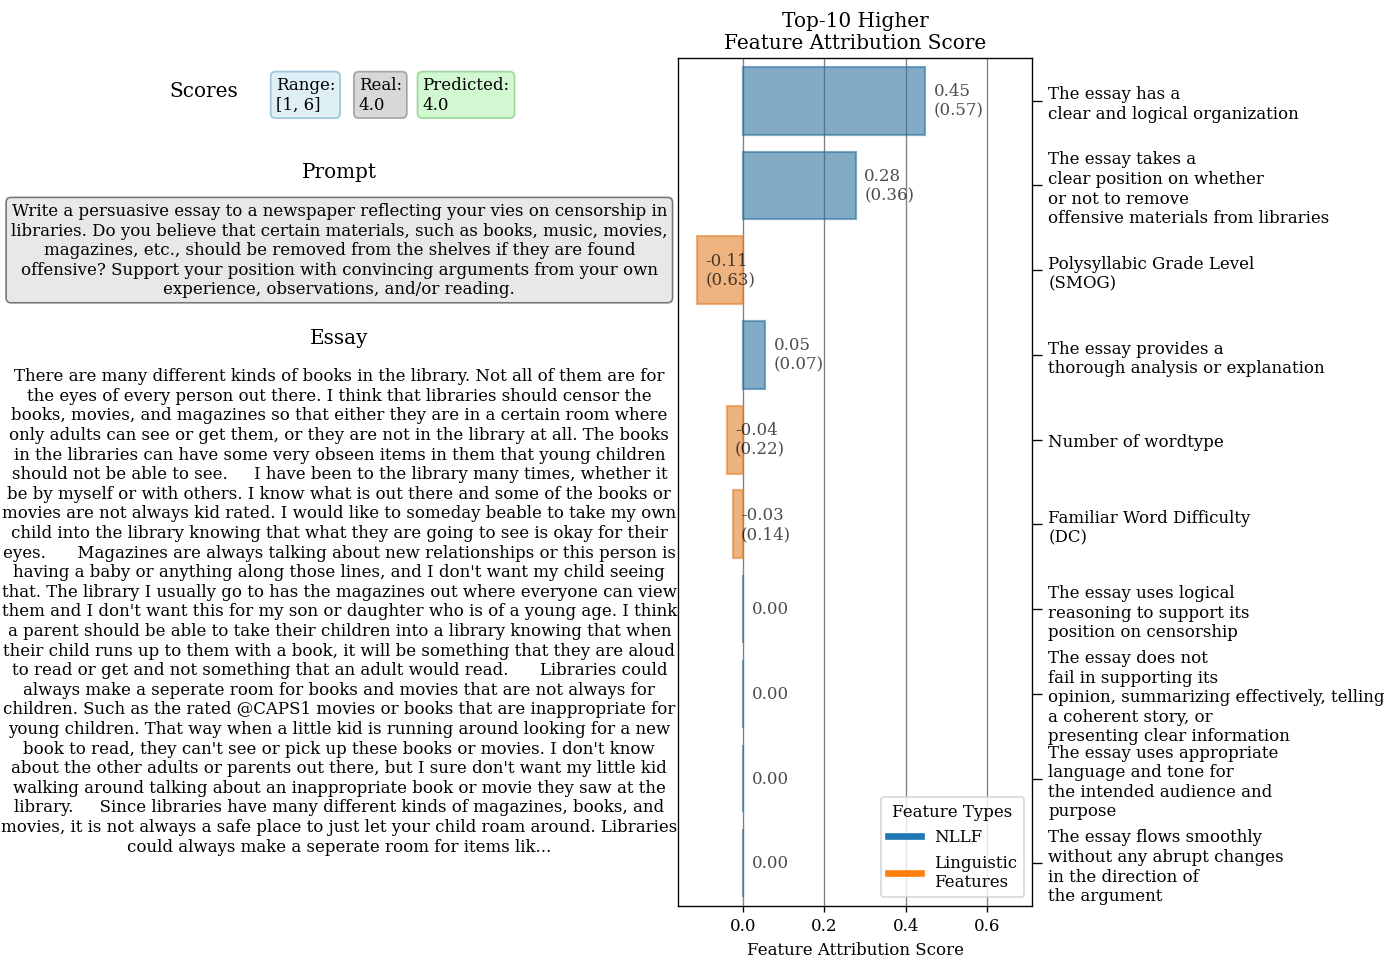

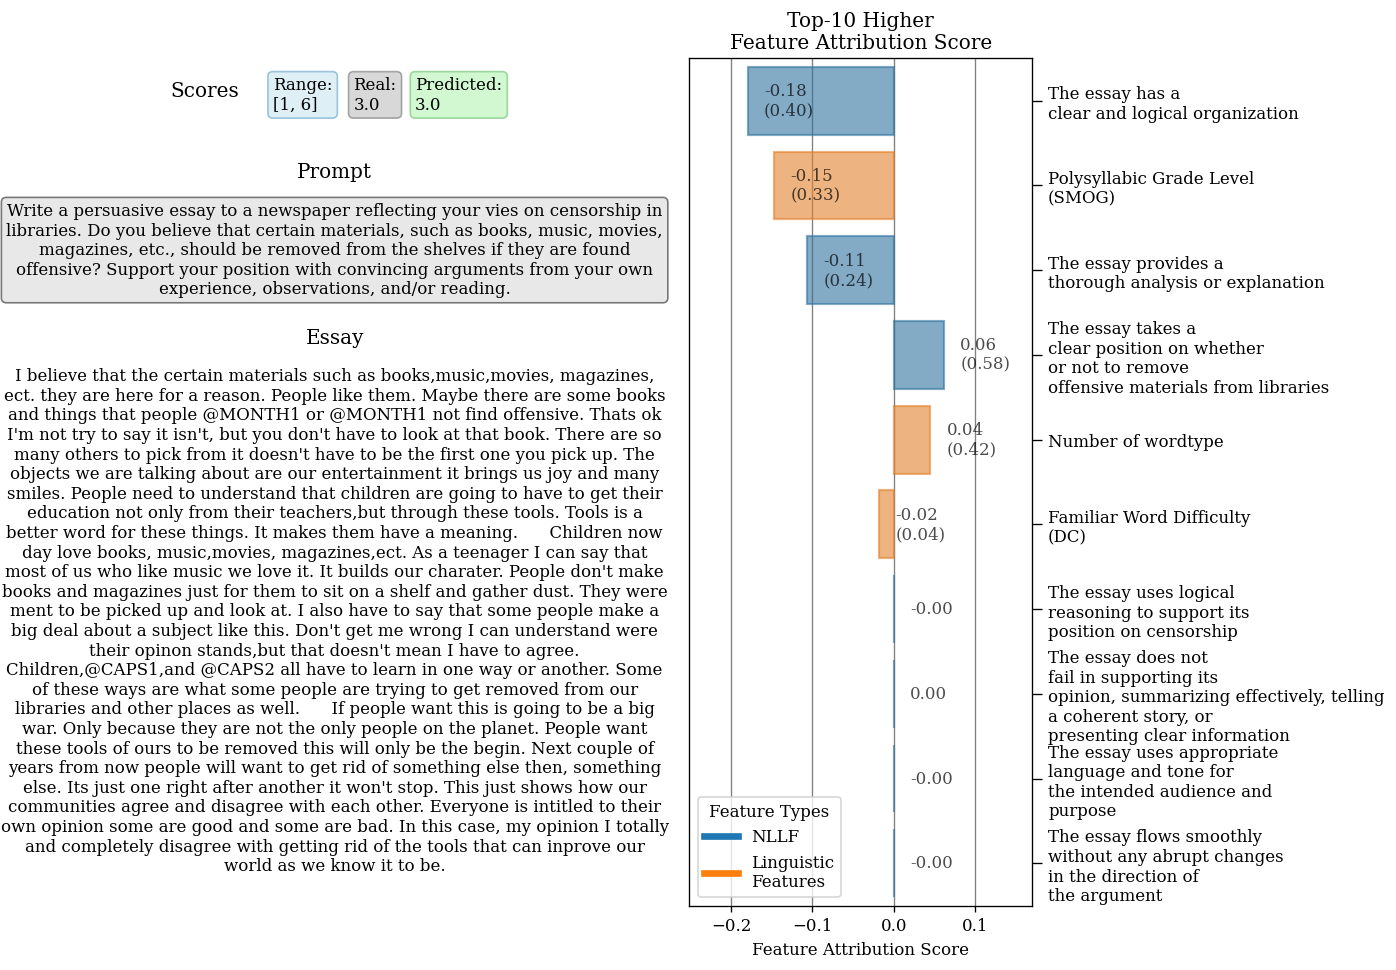

In [3]:
## SIGNAL_FILTERING
gt_1_name = "../ulra_paper/weak_signal/data/train.csv"
gt_2_name = "../llm/weak_signal/data/train.csv" if WEAK_SIGNAL_NAME == "llm" else "../signal_clustering/weak_signal/data/train.csv"

df_gt_1 = pd.read_csv(gt_1_name, index_col=0)
df_gt_2 = pd.read_csv(gt_2_name, index_col=0)

df_gt = df_gt_1.copy()
df_gt["other_pred"] = df_gt_2["pred"]

def score2label(score, res=0, size=7, m=0.49, M=1.69):
    #print(score)
    step = (M-m) / (size)
    if score < step + m:
        return 1+res
    else:
        return score2label(score-step, res+1, size, m, M)

y_real_2 = df_gt["other_pred"]

m, M = np.percentile(y_real_2, 1), np.percentile(y_real_2, 99)
preds = y_real_2.apply(lambda x: score2label(x, res=S_MIN-1, size=S_MAX-S_MIN+1, m=m, M=M)).values
preds = np.array([p if S_MIN <= p and p <= S_MAX else S_MIN if p < S_MIN else S_MAX for p in preds])

df_gt["other_pred_quantize"] = preds

y_real_1 = df_gt["pred"]
m, M = np.percentile(y_real_1, 1), np.percentile(y_real_1, 99)
preds = y_real_1.apply(lambda x: score2label(x, res=S_MIN-1, size=S_MAX-S_MIN+1, m=m, M=M)).values
preds = np.array([p if S_MIN <= p and p <= S_MAX else S_MIN if p < S_MIN else S_MAX for p in preds])
df_gt["pred"] = preds

signal_filtering = 1 - ((df_gt["pred"] - df_gt["other_pred_quantize"]).abs() / (S_MAX-S_MIN))

## WEAK SIGNAL
df_gt = pd.read_csv(f"../{WEAK_SIGNAL_NAME.replace('ulra', 'ulra_paper')}/weak_signal/data/train.csv", index_col=0)

## FEATURES
df = {}
for k in ["train", "test"]:
    o = pd.read_csv(f"nllf/labels/data_nllf.csv", index_col=0)
    df[k] = o[o["split"] == k]
    if "train" in k:
        df[k]["score"] = df_gt.loc[df[k].index]["pred"]

    o = pd.read_csv(f"../ulra_paper/lf/data/data.csv", index_col=0)
    u = o[o["split"] == k].drop(columns="index split".split())
    u.columns = [f"ulra_{c}" for c in u.columns]
    df[k] = pd.concat([df[k], u], axis=1)

## SPLIT
nllf_features_name = sorted([c for c in df["train"].columns if all(bool(e in c) for e in "c)(")])
ulra_features_name = sorted([c for c in df["train"].columns if "ulra_" in c])
features_name = nllf_features_name + ulra_features_name

X_train = df["train"][features_name]
common_cols = sorted(list(X_train.columns))

y_train = df["train"]["score"] 
y_train -= y_train.min()

train_sample = pd.concat([X_train, y_train], axis=1)

## SCALER and FIT
new_best_features = np.load(f'{MODEL_PATH}/best_features.npy')
new_best_features = [str(c) for c in new_best_features]
the_scaler = StandardScaler() if SCALER_NAME == "Z" else  MinMaxScaler()
if SCALER_NAME == "Y":
    # Determine which features exist in X_train
    existing_nllf_features = [f for f in new_best_features if f in nllf_features_name]
    existing_ulra_features = [f for f in new_best_features if f in ulra_features_name]
    
    # Create transformers only for existing features
    transformers = []
    if existing_nllf_features:
        transformers.append(('minmax', MinMaxScaler(), existing_nllf_features))
    if existing_ulra_features:
        transformers.append(('standard', StandardScaler(), existing_ulra_features))

    # Create a ColumnTransformer to apply different scalers to different columns
    the_scaler = ColumnTransformer(transformers)

clf = LinearRegression(positive=NON_NEGATIVE)
X_scaled = pd.DataFrame(the_scaler.fit_transform(X_train[new_best_features]), columns=new_best_features)
clf.fit(X_scaled, y_train, sample_weight=signal_filtering)

## TEST Performance
X_test = df["test"][common_cols]
X_test_scaled = pd.DataFrame(the_scaler.transform(X_test[new_best_features]), columns=new_best_features, index=X_test.index)
y_pred = clf.predict(X_test_scaled)

df_test = df["test"].copy()[["index", "essay_id"]]
df_test["pred"] = y_pred

df_real = pd.read_csv(f"../../data/essay_set_{ESSAY_SET}.csv", index_col=0)
df_real = df_real[df_real["split"] == "test"]

df_test["test"] = df_real["domain1_score"]

y_true = df_test["test"].values
y_pred = df_test["pred"].values

m, M = np.min(y_true), np.max(y_true)
scaled_true = (S_MIN + ((pd.Series(y_true) - m) / (M - m)) * (S_MAX - S_MIN)).values

m, M = np.percentile(y_pred, 1), np.percentile(y_pred, 99) 
scale_preds = (S_MIN + ((pd.Series(y_pred) - m) / (M - m)) * (S_MAX - S_MIN)).values

coef_scaler = (S_MAX - S_MIN) / (M - m)
coef_loc = S_MIN - (m * coef_scaler)
bias = (coef_scaler*clf.intercept_)+coef_loc

METADATA["bias"] = bias

## PARAMS
clf_params = pd.Series([bias]+list(coef_scaler*clf.coef_), index=["const"] + list(clf.feature_names_in_))

METADATA["QWK"] = np.round(quadratic_weighted_kappa(scaled_true, scale_preds, S_MIN, S_MAX), 4)

# Compute confidence intervals using bootstrapping
bootstrap_coefs, ci = bootstrap(X_scaled, y_train, signal_filtering, clf, coef_scaler, coef_loc, n_bootstrap=5000)

## MODEL stats
table = compute_statistics(clf_params, bootstrap_coefs, ci)
table.index = ["const"] + list(X_scaled.columns)

significance_level = 1 - 0.95
table["p-value"] = table["P>|t|"].apply(lambda x: p_value_to_stars(x, significance_level))
table["is_ef"] = ["ulra_" in x for x in table.index]
table["is_nllf"] = [("ulra_" not in x) and ("const" != x) for x in table.index]
table["coef (std)"] = table.apply(lambda x: f"{x['coef']:.2f} ({x['std err']:.2f})", axis=1)
table["CI (95%)"] = table.apply(lambda x: f"{x['[0.025']:.2f}, {x['0.975]']:.2f}", axis=1)
table["t-test"] = table["t"].apply(lambda x: str(np.round(float(x), 2))[:4] if float(x) > 0 else str(np.round(float(x), 2))[:5])

# add names
with open("bsq_lab/output/transformed_names.json", "r") as json_file:
    nllf_transformed_names = json.load(json_file)

with open("../ulra_paper/lf/transformed_names.json", "r") as json_file:
    ef_transformed_names = json.load(json_file)

rename = {**ef_transformed_names, **nllf_transformed_names}

for c in X_scaled.columns:
    print(
        f"feature: {rename[c]}", 
        f"Corr.: {X_scaled[c].corr(y_train):.2f}", 
        f"Mean: {X_train[c].describe().to_dict()['mean']}",
        "\n",
        sep="\n"
    )

show_table = table.sort_values("|coef|", ascending=False)["coef (std)  CI (95%)  t-test  p-value".split("  ")]
show_table.index = [rename[ix] if ix in rename else ix for ix in show_table.index]

# to latex
METADATA["SHOW_TABLE"] = show_table.to_latex()

# most significants
most_significant_significant_features = pd.concat([
    table[table["is_ef"]].sort_values(by="|coef|", ascending=False).head(5)["coef  coef (std)  [0.025  0.975]  CI (95%)  |t|  is_ef  is_nllf".split("  ")],
    table[table["is_nllf"]].sort_values(by="|coef|", ascending=False).head(5)["coef  coef (std)  [0.025  0.975]  CI (95%)  |t|  is_ef  is_nllf".split("  ")]
])

most_significant_significant_features.index = [rename[k] if k in rename else k for k in most_significant_significant_features.index ]
# print best features
METADATA["BEST_FEATURES"] = most_significant_significant_features.to_latex()
most_significant_significant_features.to_csv(f"{MODEL_PATH}/BEST_FEATURES.csv")

## PLOT model
plot_model_weights(MODEL_PATH, most_significant_significant_features, bias)

## GENERATE IG on test
text = pd.read_csv(f"../../data/essay_set_{ESSAY_SET}.csv", index_col=0).set_index("essay_id")
X_t = X_test_scaled.copy()
X_t["const"] = 1
integrated_gradients = X_t * clf_params
integrated_gradients["essay_id"] = df["test"]["essay_id"]
integrated_gradients["test"] = scaled_true
integrated_gradients["pred"] = scale_preds
integrated_gradients["essay"] = integrated_gradients["essay_id"].apply(lambda x: text.loc[x]["essay"])

# select examples
integrated_gradients = integrated_gradients.loc[(integrated_gradients["test"] - integrated_gradients["pred"]).abs().sort_values(ascending=True).index]
examples = integrated_gradients["essay_id"]
integrated_gradients.to_csv(f"{MODEL_PATH}/integrated_gradients.csv")

# prompt
with open('../../data/question.json', 'r') as f:
    meta_type = json.load(f)

p = meta_type[str(ESSAY_SET)]["question"]

## PLOT examples

examples_ids = []
# Example usage with rename dictionary
for ix in range(NUM_EXAMPLES):
    essay_id = examples.iloc[ix]
    plot_essay_feature_importance(
        model_path=MODEL_PATH,
        igs=integrated_gradients,
        prompt = meta_type[str(ESSAY_SET)]["question"],
        essay_id=essay_id, 
        rename=rename, 
        k=10, 
        max_chars=1950, 
        move_text=-0.06)
    examples_ids.append(essay_id)

METADATA["EXAMPLE_IDS"] = str(examples_ids)   
    
# SAVE meta
# Save the dictionary as a JSON file
with open(f"{MODEL_PATH}/METADATA.json", "w") as json_file:
    json.dump(METADATA, json_file, indent=4)

In [4]:
# Assuming `rename` is a dictionary that maps old index names to new names
o = table
o.index = [rename[ix] if ix in rename else ix for ix in table.index]

# Formatting the columns to two decimal places
o_formatted = o.copy()
for col in "coef  std err  [0.025  0.975]".split("  "):
    o_formatted[col] = o[col].apply(lambda x: f"{x:.2f}")

# Generating LaTeX table
print(o_formatted["coef  std err  [0.025  0.975]".split("  ")].to_latex())

\begin{tabular}{lllll}
\toprule
 & coef & std err & [0.025 & 0.975] \\
\midrule
const & 3.37 & 0.03 & 3.32 & 3.42 \\
The essay has a clear and logical organization & 0.42 & 0.08 & 0.26 & 0.57 \\
The essay uses logical reasoning to support its position on censorship & 0.00 & 0.00 & 0.00 & 0.00 \\
The essay does not fail in supporting its opinion, summarizing effectively, telling a coherent story, or presenting clear information & 0.00 & 0.02 & 0.00 & 0.06 \\
The essay uses appropriate language and tone for the intended audience and purpose & 0.00 & 0.01 & 0.00 & 0.00 \\
The essay flows smoothly without any abrupt changes in the direction of the argument & 0.00 & 0.02 & 0.00 & 0.02 \\
The essay takes a clear position on whether or not to remove offensive materials from libraries & 0.34 & 0.07 & 0.20 & 0.48 \\
The essay maintains a consistent length of responses without being overly brief or rambling and repetitive & 0.00 & 0.00 & 0.00 & 0.00 \\
The essay provides a thorough analysis or e

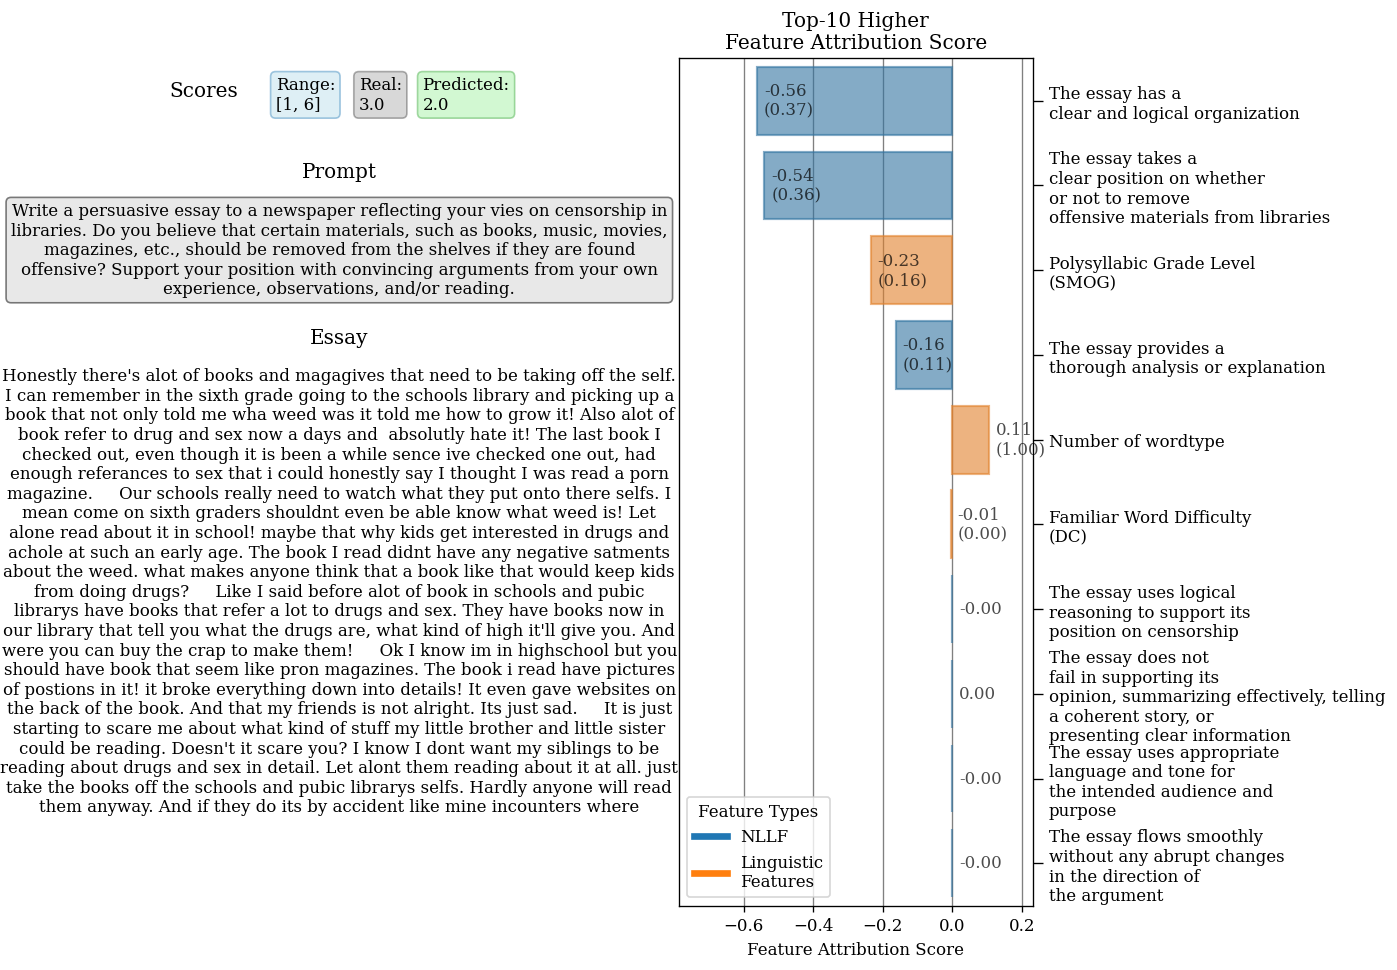

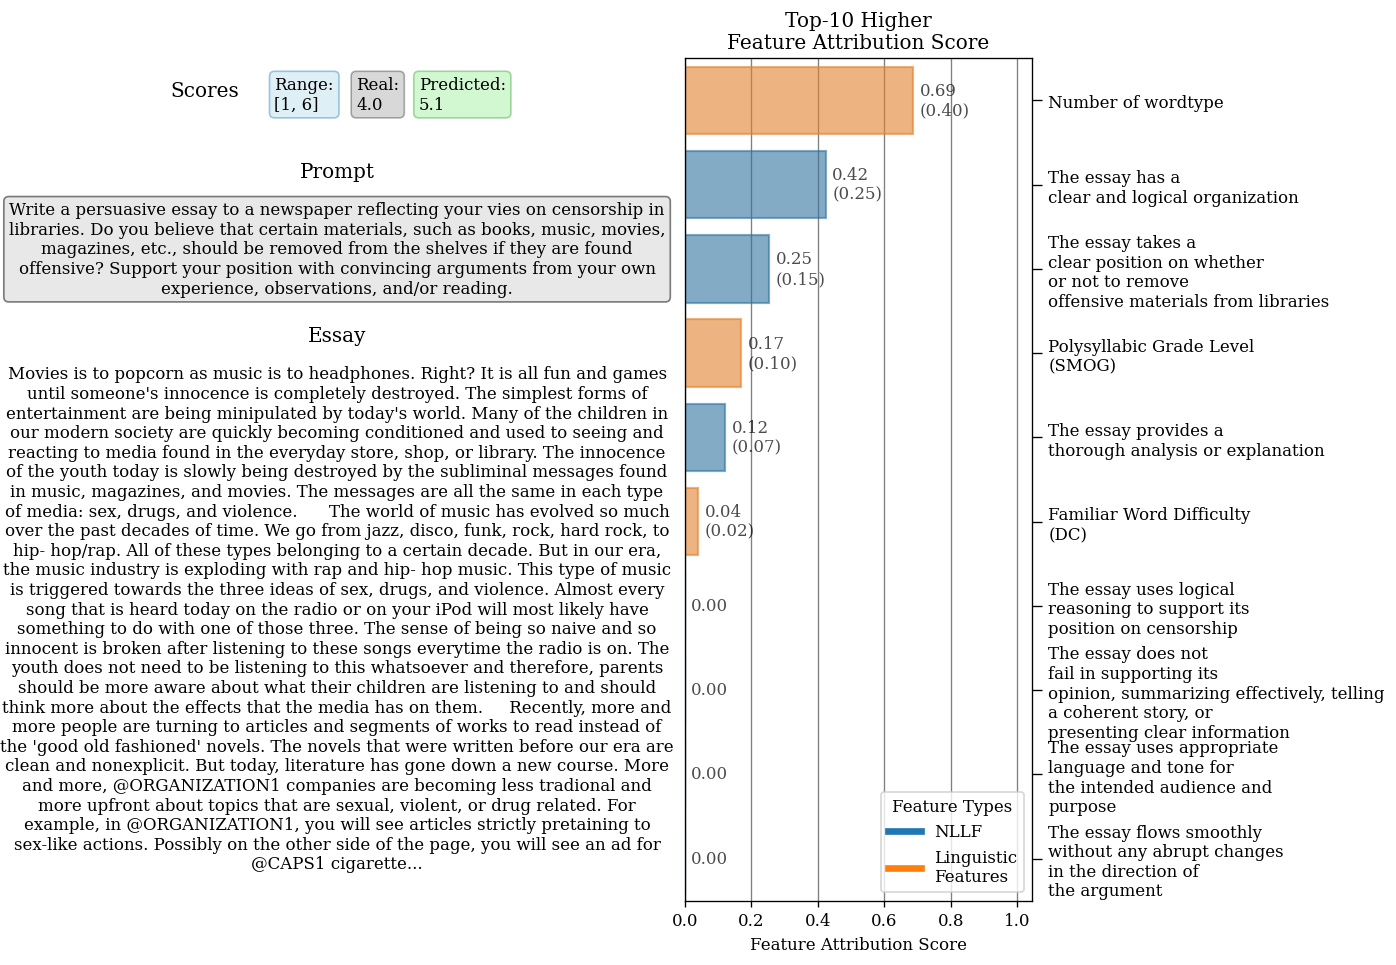

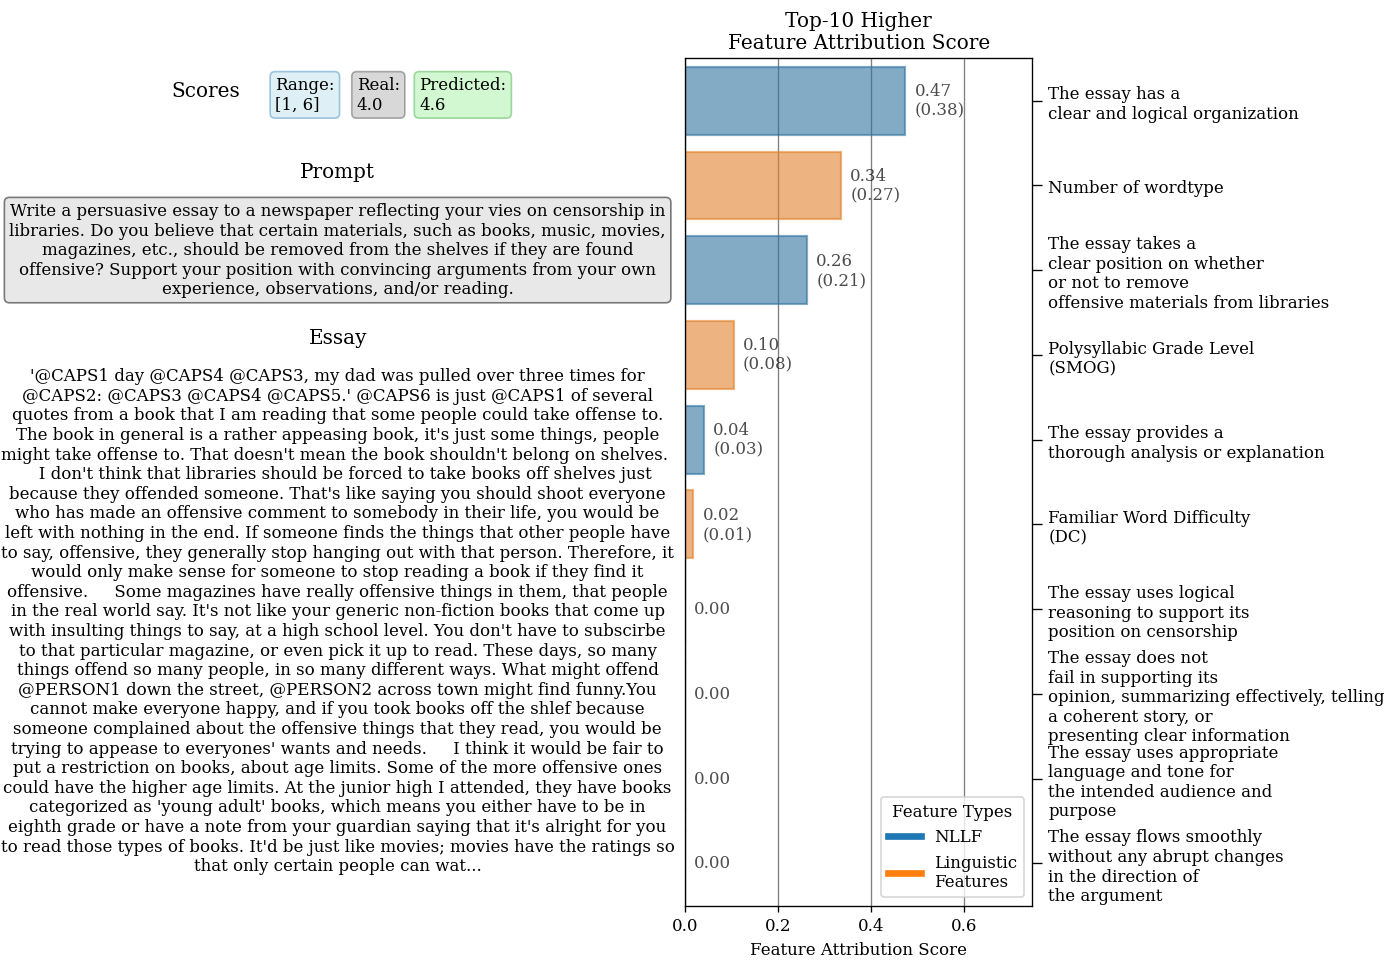

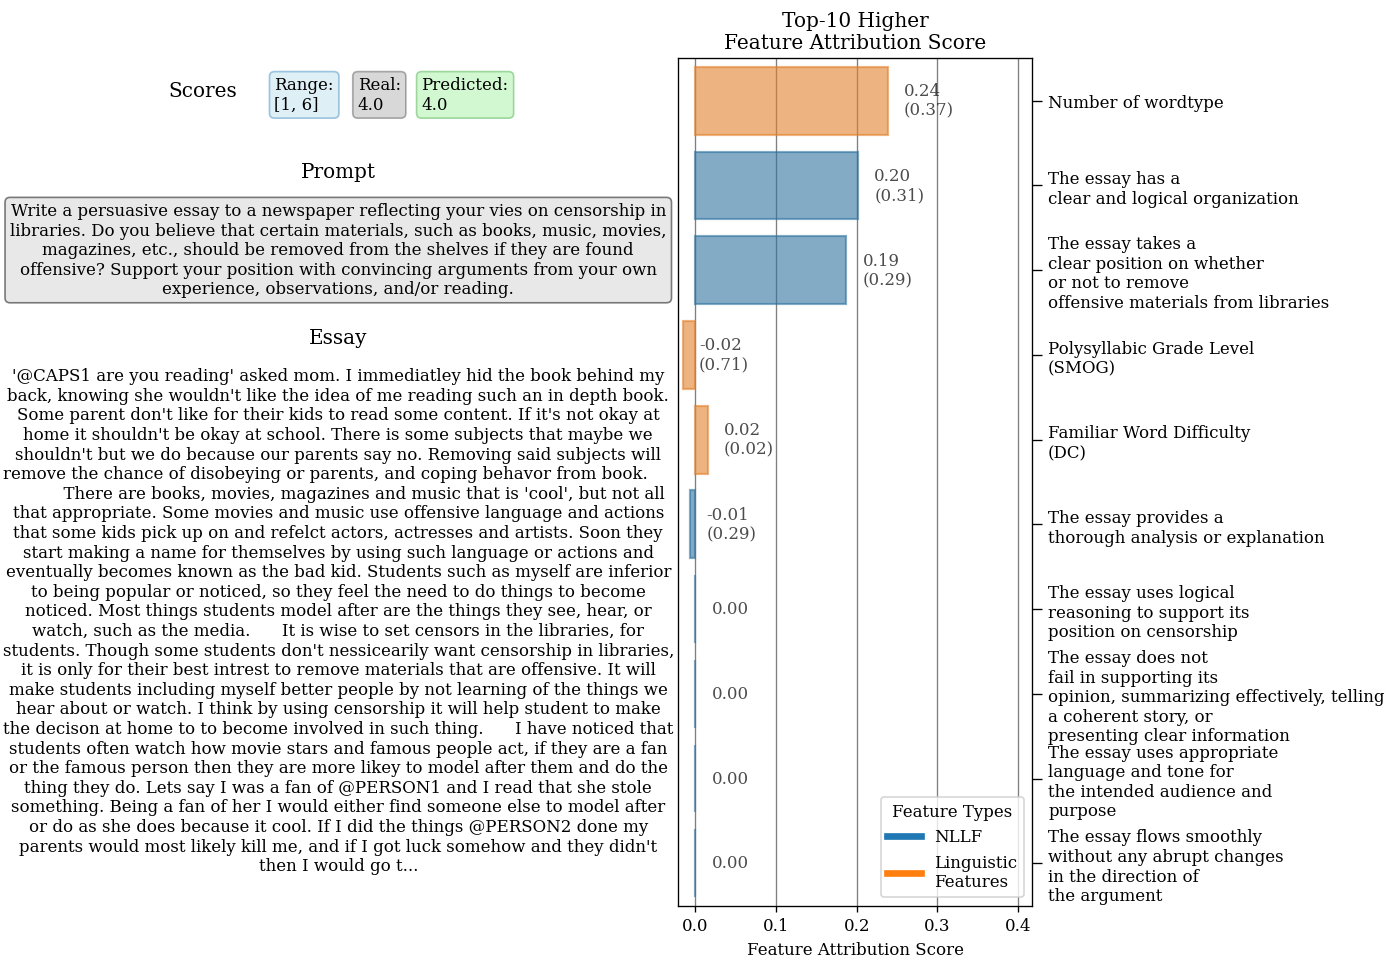

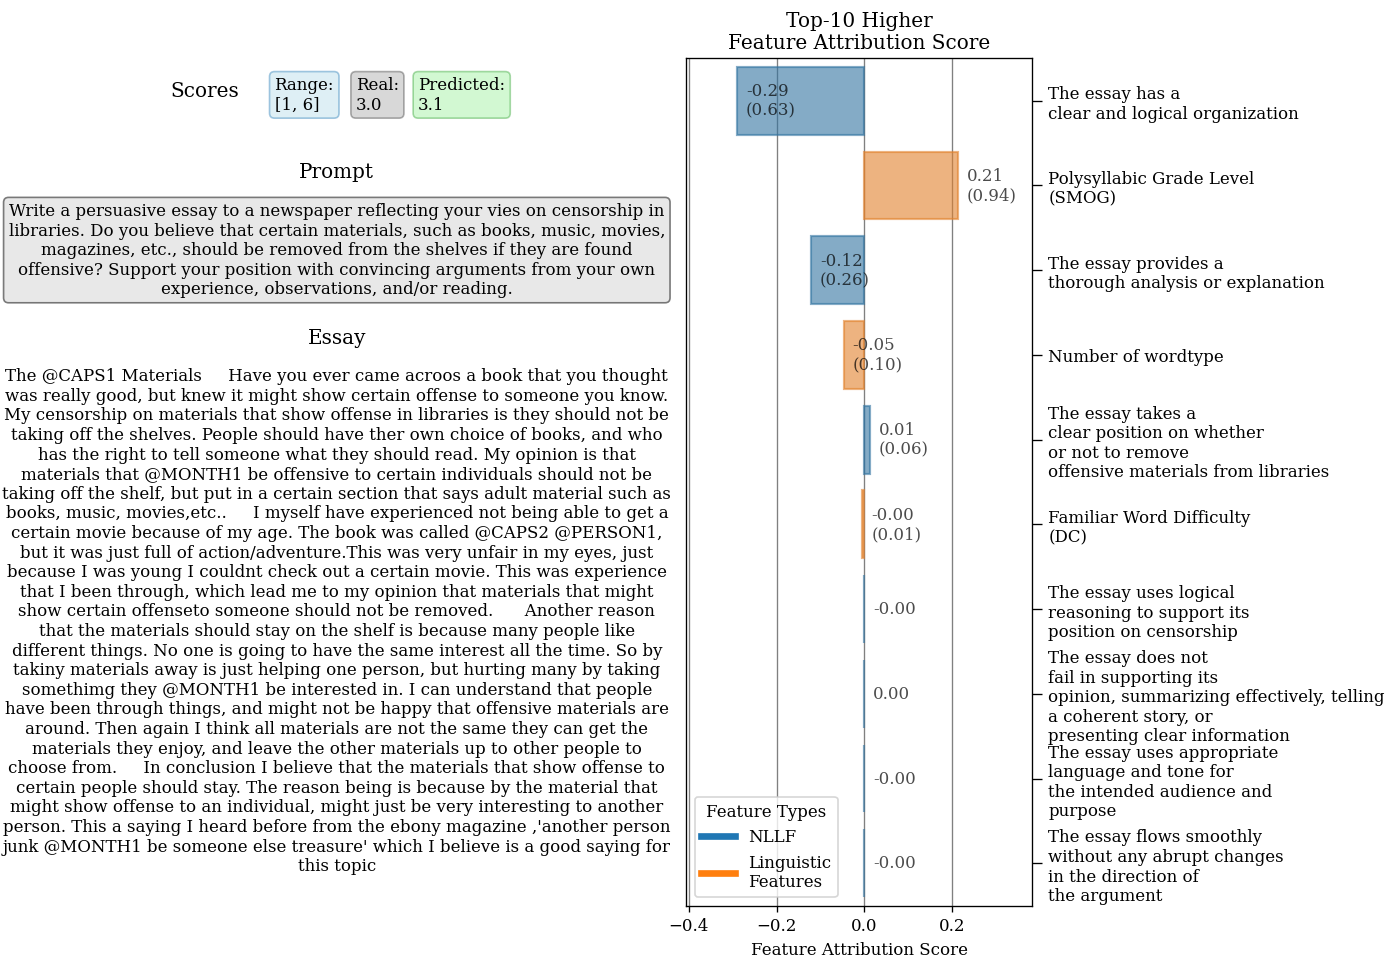

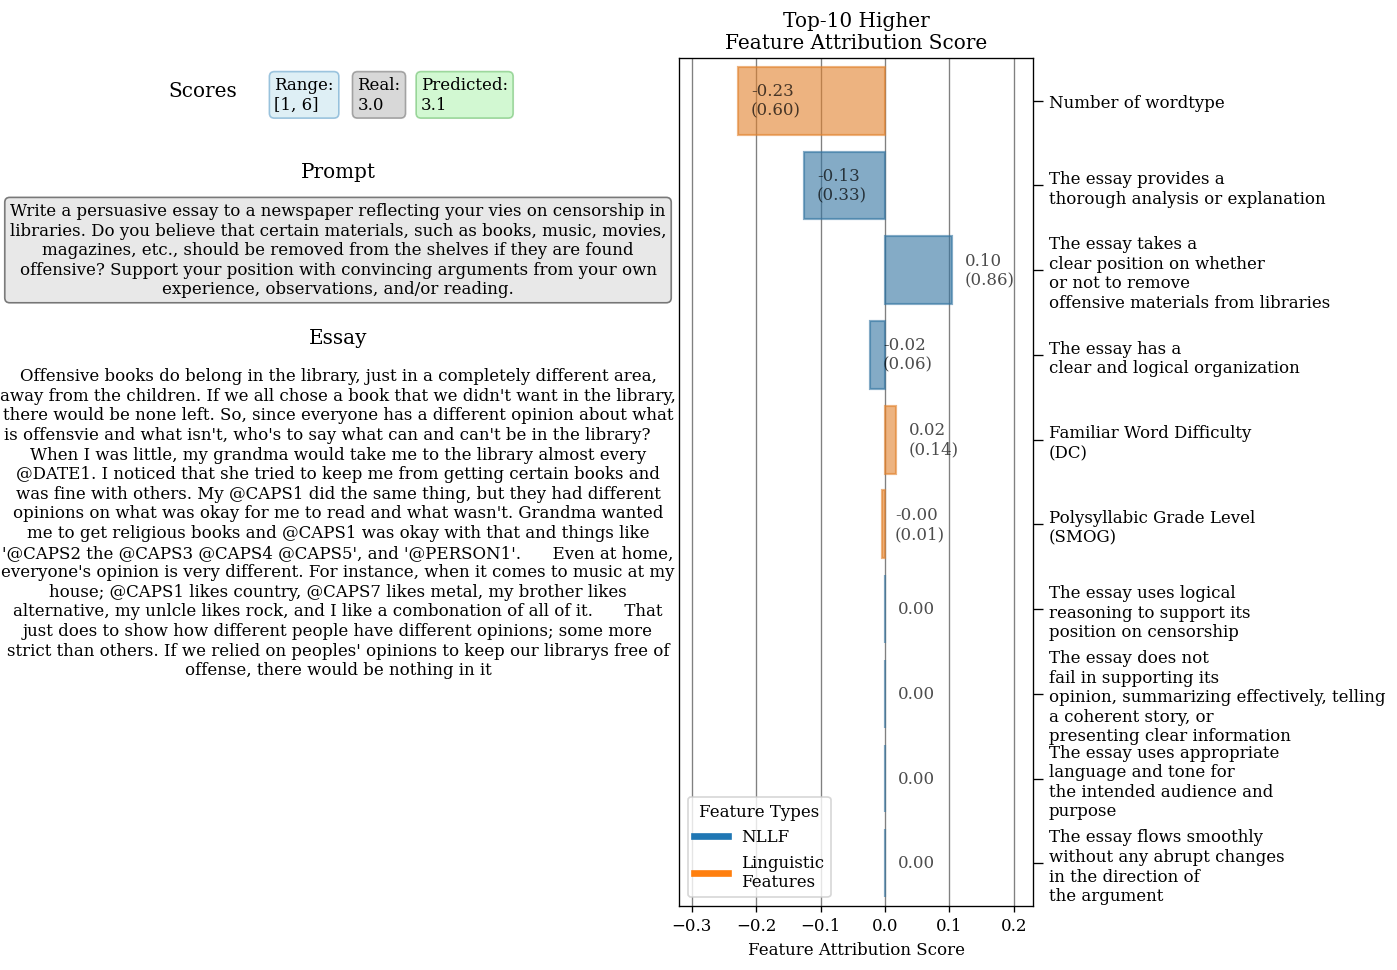

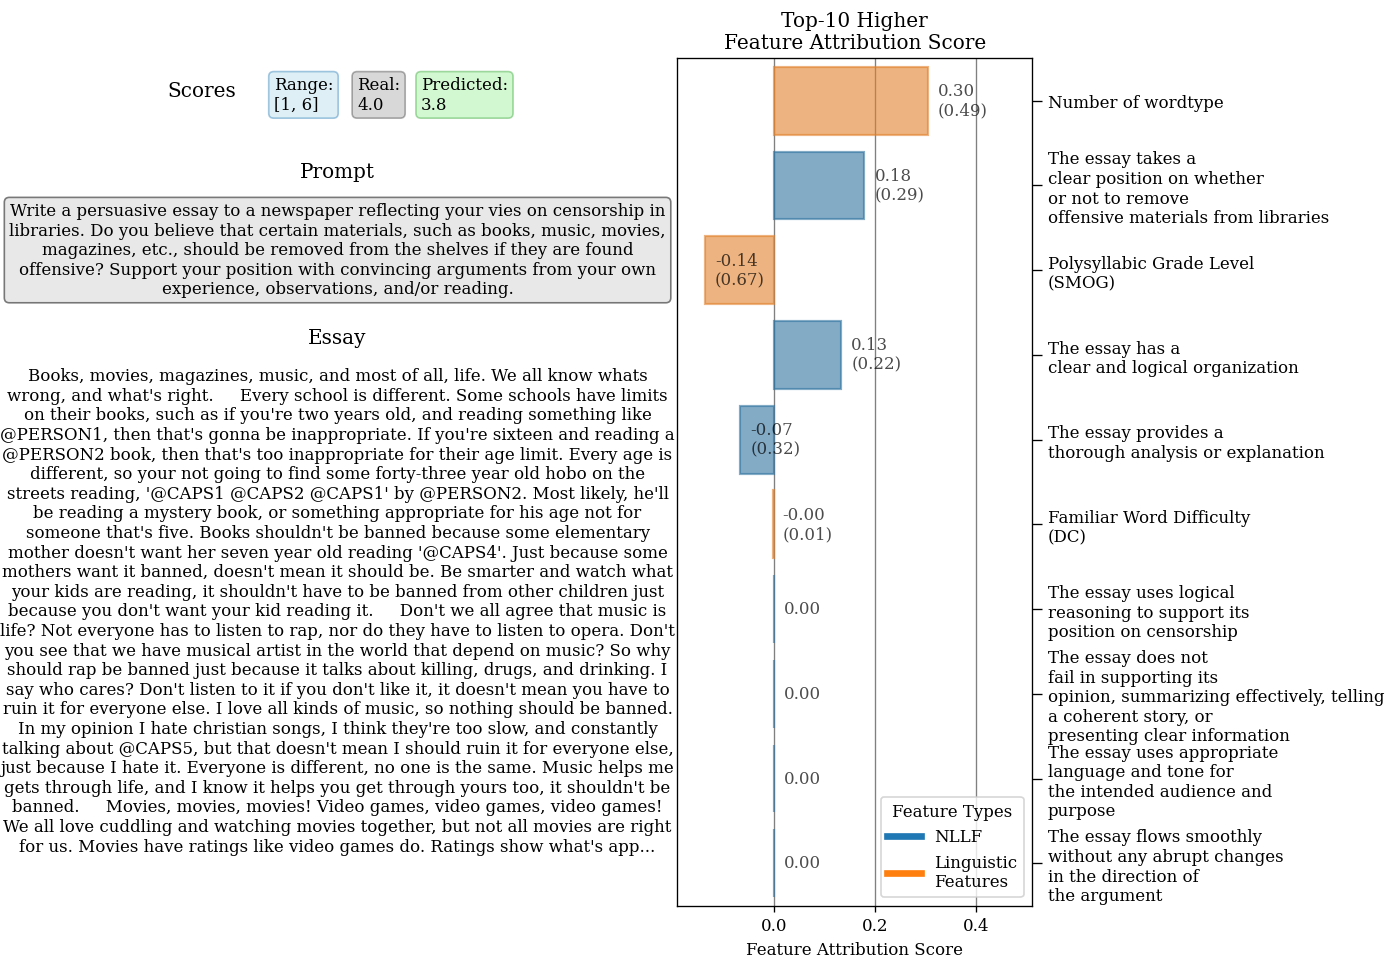

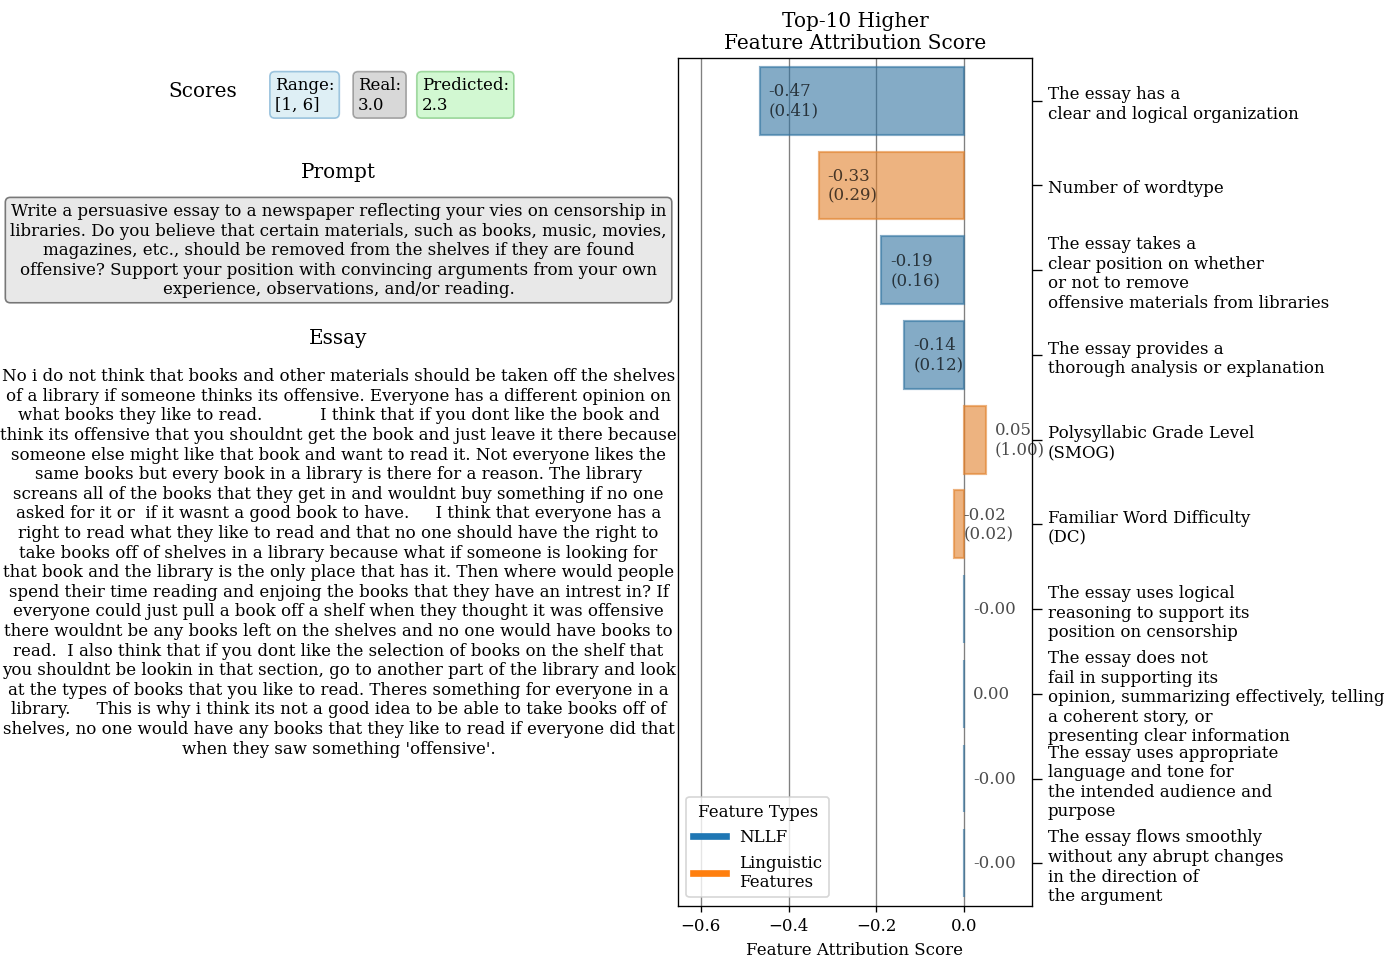

In [9]:
for essay_id in [3139, 4226, 4493, 3953, 3858, 3610, 3687, 3415]:
    plot_essay_feature_importance(
        model_path=MODEL_PATH,
        igs=integrated_gradients,
        prompt = meta_type[str(ESSAY_SET)]["question"],
        essay_id=essay_id, 
        rename=rename, 
        k=10, 
        max_chars=1950, 
        move_text=-0.06)

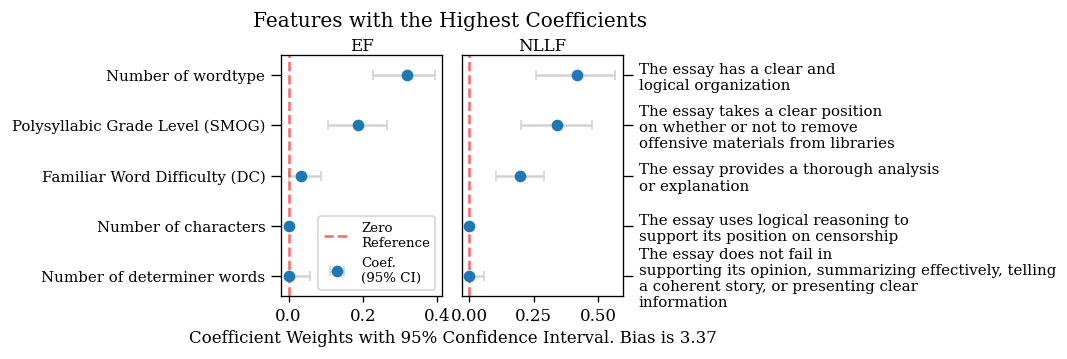

In [10]:
def new_plot_model_weights(model_path, significant_features, bias):
    # Create a vertical layout with 2 subplots
    fig, ax = plt.subplots(1, 2, figsize=(9, 3), dpi=120)  # Slightly larger for better readability

    dx = 0.3
    eps = 0.1

    # EF Plot (Top 5)
    mask_ef = significant_features["is_ef"]
    coef_top = significant_features[mask_ef].iloc[:5]["coef"][::-1]
    ci_top_lower = significant_features[mask_ef].iloc[:5]["[0.025"][::-1]
    ci_top_upper = significant_features[mask_ef].iloc[:5]["0.975]"][::-1]

    ax[0].errorbar(coef_top, range(coef_top.shape[0]), 
                xerr=[coef_top - ci_top_lower, ci_top_upper - coef_top], 
                fmt='o', color='tab:blue', ecolor='lightgray', capsize=3, label=f"Coef.\n(95% CI)")

    # NLLF Plot (Top 5)
    mask_nllf = significant_features["is_nllf"]
    coef_bottom = significant_features[mask_nllf].iloc[:5]["coef"][::-1]
    ci_bottom_lower = significant_features[mask_nllf].iloc[:5]["[0.025"][::-1]
    ci_bottom_upper = significant_features[mask_nllf].iloc[:5]["0.975]"][::-1]

    ax[1].errorbar(coef_bottom, range(coef_bottom.shape[0]), 
                xerr=[coef_bottom - ci_bottom_lower, ci_bottom_upper - coef_bottom], 
                fmt='o', color='tab:blue', ecolor='lightgray', capsize=3, label="Coef.\n(95% CI)")

    # Add horizontal reference lines at 0 (for both plots)
    ax[0].axvline(x=0, color="red", linestyle="--", alpha=0.6, label="Zero\nReference")
    ax[1].axvline(x=0, color="red", linestyle="--", alpha=0.6, label="Zero Reference")


    ll_nllf = 6
    textstr_nllf = lambda ix: f"{ix}" if len(ix.split(' ')) <= ll_nllf else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}" if len(ix.split(' '))<=ll_nllf*2 else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[2*ll_nllf:3*ll_nllf]).strip()}" if len(ix.split(' ')) <= 3*ll_nllf else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[2*ll_nllf:3*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[3*ll_nllf:4*ll_nllf]).strip()}" if len(ix.split(' ')) <= 4*ll_nllf else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[2*ll_nllf:3*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[3*ll_nllf:4*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[4*ll_nllf:]).strip()}"
            
    ll_ef = 6
    textstr_ef = lambda ix: f"{ix}" if len(ix.split(' ')) <= ll_ef else f"{' '.join(ix.split(' ')[:ll_ef]).strip()}\n{' '.join(ix.split(' ')[ll_ef:2*ll_ef]).strip()}" if len(ix.split(' '))<=ll_ef*2 else f"{' '.join(ix.split(' ')[:ll_ef]).strip()}\n{' '.join(ix.split(' ')[ll_ef:2*ll_ef]).strip()}\n{' '.join(ix.split(' ')[2*ll_ef:3*ll_ef]).strip()}" if len(ix.split(' ')) <= 3*ll_ef else f"{' '.join(ix.split(' ')[:ll_ef]).strip()}\n{' '.join(ix.split(' ')[ll_ef:2*ll_ef]).strip()}\n{' '.join(ix.split(' ')[2*ll_ef:3*ll_ef]).strip()}\n{' '.join(ix.split(' ')[3*ll_ef:]).strip()}"
            

    text_nllf = [
        textstr_nllf(ix)
        for k, ix in enumerate(significant_features[mask_nllf].iloc[:5].index)
    ][::-1]

    text_ef = [
        textstr_ef(ix)
        for k, ix in enumerate(significant_features[mask_ef].iloc[:5].index)
    ][::-1]


    # Set y-axis labels with feature names for both plots
    ax[0].set_yticks(range(coef_top.shape[0]))
    ax[0].set_yticklabels(text_ef, fontsize=9)  # Top 5 features (EF)

    ax[1].set_yticks(range(coef_bottom.shape[0]))
    ax[1].set_yticklabels(text_nllf, fontsize=9)  # Last 5 features (NLLF)

    ax[0].set_ylim(-dx-eps, max(coef_top.shape[0], coef_bottom.shape[0])-1+dx+eps)
    ax[1].set_ylim(-dx-eps, max(coef_top.shape[0], coef_bottom.shape[0])-1+dx+eps)

    # Set updated titles
    ax[0].set_title("EF", fontsize=10, pad=1)
    ax[1].set_title("NLLF", fontsize=10, pad=1)

    fig.suptitle("Features with the Highest Coefficients ", ha="center", fontsize=12, y=.92, x=0.425)

    # Set global x-axis label
    fig.text(0.425, 0.0, f"Coefficient Weights with 95% Confidence Interval. Bias is {bias:.2f}", ha='center', fontsize=10)

    # Move the y-ticks to the right
    ax[0].tick_params(axis='y', direction='out', length=6, labelright=False, labelleft=True, right=False, left=True)
    ax[1].tick_params(axis='y', direction='out', length=6, labelright=True, labelleft=False, right=True, left=False)

    # Add legends
    ax[0].legend(loc="best", fontsize=8)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Save the figure
    plt.savefig(f"{model_path}/new_coefficient_analysis.pdf", bbox_inches='tight', transparent=True)

    # Show the plot
    plt.show()

## PLOT model
new_plot_model_weights(MODEL_PATH, most_significant_significant_features, bias)